# Predicting Short-Term Permit Applications and Housing Supply in New Orleans

## Milestone 2: Additional Extraction, Transform, and Load + Exploratory Data Analysis
**Author:** Maya Gore  
**Github:** https://github.com/mayaagore/mayaagore.github.io/tree/main  
**Webpage:** https://mayaagore.github.io/     
**Data Source:** City of New Orleans, New Orleans Tax Assessor's Office (courtesy of Benjamin Eckel)

---
# I. Introduction
### Project Overview & Plan
If you want to spark a lively debate around a New Orleans dinner table, bring up Airbnb.
Regulating short-term rentals (STR) has come to represent a debate about affordability, cultural
stability, and the responsibilities of local government.  
  
New Orleans provides a particularly interesting setting for studying these dynamics becuase the city has introduced several waves of STR regulation over the past decade. After legalizing STRs in 2016, the City began tightening restrictions in response to community concerns. In August 2019, the City adopted regulations to tighten zoning limitations and require individual permit holders to have homestead tax exemptions and occupancy limits for the permitted property. In the natural rhythm of the city, STR underwent a third regulatory wave in 2023 alongside cost-of-living concerns from the COVID-19 pandemic. Stricter regulations were passed allowing up to three STR permits per city block distributed by lottery system and applied to within Orleans Parish, excepting the French Quarter and Garden District, where STRs are entirely banned.  
  
This project will combine publically available STR permit data from the City of New Orleans and third-party scraped property-evel records from the Orleans Parish Assessor to examine how neihgborhoods respond to STR regulation, and predict how particular types of units will respond?   
  
**Central Research Quesions:**    
* Can we predict which properties are likely to apply for an STR permit? 
    * And as an extension, do STR permit regulations cause units to transition into long-term housing supply? Can a propensity score based on these predictions improve measure of policy impact?
* Which permitted STRs are most likely to return to the long-term rental market? Can identifying 'vulnerable' properties help inform permit allocation?

To answer these questions, I contruct a property-level panel dtaset spanning from 2015-2021, mergin New Orleans Assessor data with the city's STR permit application records. Property characteristics such as assessed value, building size, land area, homestead exemption status, and census tract will act as predictors for STR entry and exit decisions.

# II. Data
## Project Datasets   
  
### 1. STR Permit Applications, City of New Orleans *(primary dataset for M1)*
**Source:** https://data.nola.gov/Housing-Land-Use-and-Blight/Short-Term-Rental-Permit-Applications/en36-xvxg/about_data    
**Coverage:** individual permit application,  2017 to 2025, 35,952 applications   
  
This is the core dataset and the primary data examined for Milestone 1. It contains the application for every STR permit in New Orleans including withdrawls and rejections, and captures the permit type, residential subtype, status (and date of issue, date of application), operator name, capacity, and GPS coordinates. It captures the regulatory history of the STR market in New Orleans.  
  
This dataset can answer questions about whether STR permit activity changed around periods of regulatory change. 

### 2. New Orleans Assessor Data (scraped from the Orleans Parish Assessor's Office courtesy of Benjamin Eckel)
**Source:** https://github.com/bhelx/nola-assessor-data   
**Coverage:** one row per property, 2015 to 2021

This 2021 scrape of the assessor's page (which has since updated with heightened security measures) captures every property in the city, including: address, parcel number, building area, land area, property class. By year it also captures: assessed land value, building value, total value and homestead exemption. There is a separate dataset from the same source with one row per recorded property sale, with date, price, grantor, and grantee. 
  
### 3. Census Tract Boundaries
**Source:** https://usa.ipums.org/usa-action/revisions#revision_2_27_2025    
**Coverage:** all census tracts within Orleans Parish, 2020
  
Through the U.S. Census TIGER/Line  Shapefiles per year, I matched coordinates provided for each property in the city to its census tract. 

  
*This panel is contructed at the property x year levle. A property is flagged as having applied for and STR in a given year if it submitted a permit application in that year (matched on address and application year). Application over approval status was used as a flag, as application is a behavioral choice by the property owner.*

## II.A Data Processing
### II.A.1 Load

#### Assessor Data: Load and Examine
Data is loaded from the Eckel's SQL database scraped from the Orleans Parish Assessor's Office. Three of his tables are of interest: properties, property values, and property sales. The postgresql databases were saved locally for ease, but are available at the link above.

In [58]:
import pandas as pd
from sqlalchemy import create_engine

engine = create_engine("postgresql://mayagore@localhost/nola_assessor_scraper")

# see what tables exist
df = pd.read_sql("SELECT table_name FROM information_schema.tables WHERE table_schema = 'public'", engine)
print(df)

          table_name
0  geography_columns
1   geometry_columns
2    spatial_ref_sys
3    property_values
4  schema_migrations
5         properties
6     property_sales


In [59]:
# take a look at the data
properties = pd.read_sql("SELECT * FROM properties", engine)
property_values = pd.read_sql("SELECT * FROM property_values", engine)
property_sales = pd.read_sql("SELECT * FROM property_sales", engine)

print(properties.shape)
print(properties.head())

(159555, 16)
     id             assessor_id               owner_name  land_area_sq_ft  \
0  2625  1029-ORETHACHALEYBLRTA       1029 OC HALEY, LLC            19729   
1  2810          1273-STDENISST        1273 ST DENIS LLC             4000   
2  2732         1208-SRAMPARTST           LEVIN ANDREW J             3300   
3  2746          1216-HILLARYST  1216 HILLARY STREET LLC             3300   
4  2748         1223-BARRACKSST        TAYLOR JIMMIE RAY             1410   

         location_address                                    mailing_address  \
0  1029 ORETHA C HALEY BL  2259 ORETHA C HALEY BLVD \n NEW ORLEANS, LA 70113   
1        1273 ST DENIS ST     3535 CANAL ST STE 100 \n NEW ORLEANS, LA 70119   
2       1208 S RAMPART ST         1210 S RAMPART ST \n NEW ORLEANS, LA 70113   
3         1216 HILLARY ST              7616 PLUM ST \n NEW ORLEANS, LA 70118   
4        1223 BARRACKS ST          1223 BARRACKS ST \n NEW ORLEANS, LA 70116   

  property_class municipal_district  assess

In [60]:
# check columns
print("=== property_values columns ===")
print(property_values.columns.tolist())
print(property_values.shape)

print("\n=== property_sales columns ===")
print(property_sales.columns.tolist())
print(property_sales.shape)

=== property_values columns ===
['id', 'property_id', 'year', 'land_value', 'building_value', 'total_value', 'assessed_land_value', 'assessed_building_value', 'total_assessed_value', 'homestead_exemption_value', 'taxable_assessment', 'inserted_at', 'updated_at', 'neighborhood_id', 'age_freeze', 'disability_freeze', 'assment_change', 'tax_contract']
(1114016, 18)

=== property_sales columns ===
['id', 'property_id', 'date', 'price', 'grantor', 'grantee', 'notarial_archive_number', 'instrument_number', 'inserted_at', 'updated_at']
(679785, 10)


In [61]:
# in property_sales, convert date to datetime and extract year
property_sales["year"] = pd.to_datetime(property_sales["date"], errors="coerce").dt.year

# check how many bad dates there are
bad_dates = property_sales[property_sales["year"].isna()]
print(f"rows with unparseable dates: {len(bad_dates)}")

rows with unparseable dates: 93


In [62]:
# check sales observations for multiple sales of a property in the same year
sales_per_prop_year = property_sales.groupby(["property_id", "year"]).size()
extra_rows = (sales_per_prop_year - 1).sum()
print(f"multiple sales per property-year: {extra_rows}")

# check sales for multiple sales of a property in the same year
sales_per_prop_year = property_sales.groupby(["property_id", "year"]).size()
extra_rows = (sales_per_prop_year - 1).sum()
print(f"multiple sales per property-year: {extra_rows}")
print(f"expected panel size after join: {len(property_values) + extra_rows}")

# keep the most recent sale per property-year
property_sales_dedup = property_sales.sort_values('date', ascending=False).drop_duplicates(subset=['property_id', 'year'], keep='first')
print(f"rows before: {len(property_sales)}")
print(f"rows after: {len(property_sales_dedup)}")

# keep the most recent sale per property-year
property_sales_dedup = property_sales.sort_values('date', ascending=False).drop_duplicates(subset=['property_id', 'year'], keep='first')
print(f"rows before: {len(property_sales)}")
print(f"rows after: {len(property_sales_dedup)}")

multiple sales per property-year: 112158
multiple sales per property-year: 112158
expected panel size after join: 1226174
rows before: 679785
rows after: 567625
rows before: 679785
rows after: 567625


In [63]:
## merge property_sales_dedup with properties and property_values to create a panel dataset of properties x year, with sales info attached where available
# extract year from property_sales_dedup date
property_sales_dedup['year'] = pd.to_datetime(property_sales_dedup['date'], errors="coerce").dt.year

# start with properties x year
panel = properties.merge(property_values, left_on="id", right_on="property_id", how="left")

# attach sales by property x year (left join, will generate nulls if no sales)
panel = panel.merge(property_sales_dedup[['property_id', 'year', 'date', 'price', 'grantor', 'grantee']], on=['property_id', 'year'], how='left')

# for any duplicate sales in a year
dupes = property_sales_dedup.groupby(["property_id", "year"]).size()
print(dupes[dupes > 1].value_counts())

# create quick homestead indicator based on property_values
panel["is_homestead"] = panel["homestead_exemption_value"] > 0

# take a look at the resulting panel
print(panel.shape)
print(panel.columns.tolist())
print(panel['year'].value_counts().sort_index())
print(panel.head(10))

Series([], Name: count, dtype: int64)
(1114016, 39)
['id_x', 'assessor_id', 'owner_name', 'land_area_sq_ft', 'location_address', 'mailing_address', 'property_class', 'municipal_district', 'assessment_area', 'tax_bill_number', 'inserted_at_x', 'updated_at_x', 'lng_lat_point', 'parcel_no', 'neighborhood_id_x', 'building_area_sq_ft', 'id_y', 'property_id', 'year', 'land_value', 'building_value', 'total_value', 'assessed_land_value', 'assessed_building_value', 'total_assessed_value', 'homestead_exemption_value', 'taxable_assessment', 'inserted_at_y', 'updated_at_y', 'neighborhood_id_y', 'age_freeze', 'disability_freeze', 'assment_change', 'tax_contract', 'date', 'price', 'grantor', 'grantee', 'is_homestead']
year
2015.0    158508
2016.0    159086
2017.0    159551
2018.0    157912
2019.0    157914
2020.0    157667
2021.0    157468
Name: count, dtype: int64
   id_x             assessor_id          owner_name  land_area_sq_ft  \
0  2625  1029-ORETHACHALEYBLRTA  1029 OC HALEY, LLC            1

#### STR Data: Load & Examine
STR permit application data is loaded from a CSV downloaded from the City of New Orleans Open Data portal. Addresses are standardized to match assessor formatting as much as possible.

In [64]:
# load STR data
str_df = pd.read_csv("/Users/mayagore/Library/CloudStorage/OneDrive-TulaneUniversity/STR project/Data/STRs_cleaned.csv")

# check STR data
print("\n=== str_df columns ===")
print(str_df.columns.tolist())
print(str_df.shape)


=== str_df columns ===
['permit_number', 'address', 'permit_type', 'residential_subtype', 'current_status', 'expired', 'expiration_date', 'bedroom_limit', 'guest_occupancy_limit', 'link', 'operator_name', 'operator_phone', 'operator_email', 'operator_permit_number', 'license_holder_name', 'application_date', 'issue_date', 'reference_code', 'x', 'y', 'location', 'perm_type', 'res_type', 'status', 'exp_', 'exp_date', 'iss_date', 'app_date', 'app_moyr', 'app_year', 'operator_id', 'operator_permit_id', 'latitude', 'longitude', 'tract_geoid']
(35952, 35)


In [65]:
# standardize addresses in both dfs for matching
def clean_address(addr):
    if pd.isna(addr):
        return None
    return str(addr).upper().strip()

str_df['address_clean'] = str_df['address'].apply(clean_address)
panel['address_clean'] = panel['location_address'].apply(clean_address)

# check what they look like side by side
print("STR addresses:")
print(str_df['address_clean'].dropna().head(10))
print("\nAssessor addresses:")
print(panel['address_clean'].dropna().head(10))

STR addresses:
2     212 LOYOLA AVE UNIT 1205
4                416 PARK BLVD
6               2506 MYRTLE ST
7           1621 ST ANTHONY ST
8              217 S CORTEZ ST
9               521 ST MARY ST
10     1869 N DUPRE ST SUITE B
11                4425 EDEN ST
12          1241 CARONDELET ST
13               919 N MIRO ST
Name: address_clean, dtype: object

Assessor addresses:
0    1029 ORETHA C HALEY BL
1    1029 ORETHA C HALEY BL
2    1029 ORETHA C HALEY BL
3    1029 ORETHA C HALEY BL
4          1273 ST DENIS ST
5          1273 ST DENIS ST
6          1273 ST DENIS ST
7          1273 ST DENIS ST
8          1273 ST DENIS ST
9          1273 ST DENIS ST
Name: address_clean, dtype: object


### II.A.2 Merge
Merging the assessor panel to the STR permits is a challenge: addresses are not standardized between the datasets, and the differences in notation are varied. I try two steps:
1. match exactly whichever normalized addresses I can
2. perform a fuzzy match (using rapidfuzz, which I believe is the most up-to-date) with a threshold of 90 for the remaining unmatched addresses, first constraining by addresses with the same street number, as most of the mismatch is the the alphabetical strings. 

I match on application year along with addresses to ensure each STR permit is attached to the panel year when the property owner sought a permit, which captures the application entry decision. 
#### Address normalizing

In [66]:
# fix unit numbers in assessor data 
import re
def normalize_address(addr):
    if pd.isna(addr):
        return None
    addr = str(addr).upper().strip()
    # remove unit numbers
    addr = re.sub(r'\s+(UNIT|APT|STE|SUITE|#|LOT)\s+\S+', '', addr)
    # remove trailing numbers (assessor style numbers like "3525 PRYTANIA ST    606")
    addr = re.sub(r'\s+\d+$', '', addr)
    # remove multiple spaces
    addr = re.sub(r'\s+', ' ', addr)
    # standardize common abbreviations
    replacements = {r'\bBL\b': 'BLVD',
                    r'\bAV\b': 'AVE',
                    r'\bRD\b': 'ROAD',
                    r'\bDR\b': 'DRIVE'}
    for pattern, replacement in replacements.items():
        addr = re.sub(pattern, replacement, addr)
    # remove punctuation
    addr = re.sub(r'[^\w\s]', '', addr)
    return addr.strip()

str_df['address_norm'] = str_df['address_clean'].apply(normalize_address)
panel['address_norm'] = panel['address_clean'].apply(normalize_address)

#### Naming & Matching diagnostic

In [67]:
# street identifiers seem to be a problem--remove them and see if it helps
street_types = r'\s+(ST|AVE|BLVD|DR|RD|LN|CT|PL|TER|WAY|CIR|PKWY|HWY|TERR)\b'

panel['address_norm2'] = panel['address_norm'].str.replace(street_types, '', regex=True)
str_df['address_norm2'] = str_df['address_norm'].str.replace(street_types, '', regex=True)

panel_addrs2 = set(panel['address_norm2'].dropna().unique())
permit_addrs2 = set(str_df['address_norm2'].dropna().unique())
print(f"Overlap after stripping street types: {len(panel_addrs2 & permit_addrs2)}")

Overlap after stripping street types: 6635


In [68]:
# look at unmatched permits in detail
unmatched_permits = permit_addrs2 - panel_addrs2
print(f"Still unmatched: {len(unmatched_permits)}")
print("\nSample unmatched permits:")
for addr in sorted(list(unmatched_permits))[:10]:
    print(repr(addr))

# what do matched vs unmatched panel addresses look like?
matched_panel = panel_addrs2 & permit_addrs2
unmatched_panel = permit_addrs2 - panel_addrs2

print("\nSample MATCHED permits:")
for addr in list(matched_panel)[:10]:
    print(repr(addr))

print("\nSample UNMATCHED permits:")    
for addr in list(unmatched_panel)[:10]:
    print(repr(addr))

# find original addresses for unmatched permits
unmatched_sample = str_df[str_df['address_norm2'].isin(unmatched_permits)]['address'].head(20)
#print("\nOriginal unmatched permit addresses:")
#print(unmatched_sample.tolist())

Still unmatched: 4569

Sample unmatched permits:
'100 N TELEMACHUS'
'1001 B POLAND'
'1001 N ROCHEBLAVE'
'1001 SAINT ROCH'
'1002 ELYSIAN FIELDS'
'1002 N ROCHEBLAVE'
'1002 OPELOUSAS'
'1002 THALIA'
'1002 VERRET'
'1004 CADIZ'

Sample MATCHED permits:
'2337 CANAL'
'1122 N JOHNSON'
'1329 TOURO'
'4862 TCHOUPITOULAS'
'2705 DRYADES'
'932 SOLOMON'
'714 ROCH'
'2471 PARIS ROAD'
'2704 FRENCHMEN'
'3800 CONSTANCE'

Sample UNMATCHED permits:
'5222 TCHOUPITOULAS'
'1301 CARONDELET'
'1364 MOSS APT B'
'1512 LESSEPS'
'3925 CLAUDE REAR STRUCTURE'
'2025 DUMAINE A'
'4618 TOULOUSE'
'637 S DUPRÉ'
'1816 AMELIA'
'8949 JEANNETTE A'


#### Fuzzy merge
For addresses that did not match exactly, I apply a fuzzy match constrained by street number exact match. This resolves the issue of previous iterations of streets matching with similar names (e.g. Bourbon and Touro).

In [69]:
from rapidfuzz import process, fuzz 
import re
import numpy as np

In [70]:
# extract street numbers for better matching
def extract_street_number(addr):
    if pd.isna(addr):
        return None
    match = re.match(r'^(\d+)', str(addr))
    return match.group(1) if match else None

# 1. pull exact matches first -- on address and year
exact_merged = panel.merge(
    str_df[['address_norm', 'reference_code', 'permit_number', 'current_status', 'app_year', 'issue_date', 'permit_type', 'tract_geoid']].drop_duplicates(['address_norm', 'app_year']),
    left_on=['address_norm', 'year'],
    right_on=['address_norm', 'app_year'],
    how='left'
)

# 2. identify unmatched address+year combinations in both datasets (no STR app for that year at that address)
matched_addr_years = set(
    zip(exact_merged[exact_merged['reference_code'].notna()]['address_norm'],
        exact_merged[exact_merged['reference_code'].notna()]['year'])
)
print(f"exact matches found: {len(matched_addr_years)}")

# find unmatched address-year combos in both datasets
unmatched_panel = panel[~panel.apply(lambda x: (x['address_norm'], x['year']) in matched_addr_years, axis=1)].copy().reset_index(drop=True)
unmatched_str = str_df[~str_df.apply(lambda x: (x['address_norm'], x['app_year']) in matched_addr_years, axis=1)].copy()
print(f"unmatched panel addresses: {unmatched_panel.shape}")

# 3. fuzzy match on addresses constrained by street number
str_df['street_num'] = str_df['address_norm'].apply(extract_street_number)
unmatched_panel['street_num'] = unmatched_panel['address_norm'].apply(extract_street_number)
str_by_num = str_df.groupby('street_num')['address_norm'].apply(list).to_dict()

# define the fuzzy match function
def fuzzy_match_same_number(addr, threshold=90):
    if pd.isna(addr):
        return None, None
    num = extract_street_number(addr)
    if num is None or num not in str_by_num:
        return None, None
    candidates = str_by_num[num]
    match = process.extractOne(addr, candidates, scorer=fuzz.ratio, score_cutoff=threshold)
    if match:
        return match[0], match[1]  # return matched string and score
    return None, None

# apply to unmatched sets identified above
results = unmatched_panel['address_norm'].apply(lambda x: pd.Series(fuzzy_match_same_number(x)))
results.columns = ['matched_str_addr', 'match_score']
print(f"Fuzzy matches found: {results['matched_str_addr'].notna().sum()}")

# 4. attach fuzzy match results back to unmatched_panel
unmatched_panel['matched_str_addr'] = results['matched_str_addr'].values
unmatched_panel['match_score'] = results['match_score'].values

# fuzzy join to get STR info for fuzzy matches--make sure to remove nan addresses to match on
fuzzy_merged = unmatched_panel.merge(
    str_df[str_df['address_norm'].notna()][['address_norm', 'app_year', 'reference_code', 'permit_number', 'current_status', 'issue_date', 'permit_type', 'tract_geoid']].drop_duplicates(['address_norm', 'app_year']),
    left_on=['matched_str_addr', 'year'],
    right_on=['address_norm', 'app_year'],
    how='left',suffixes=('', '_str')    
)   

# 5. combine exact and fuzzy matches
exact_hits = exact_merged[exact_merged['reference_code'].notna()]

merged = pd.concat([exact_hits, fuzzy_merged], ignore_index=True)
merged['is_str'] = merged['reference_code'].notna()
merged['match_type'] = np.where(merged['reference_code'].isna(), 'unmatched', np.where(merged['match_score'].notna(), 'fuzzy', 'exact'))

print(f"total rows: {len(merged)}")
print(f"expected: {len(panel)} rows")
print(f"got: {len(merged)} rows")

print(merged['match_type'].value_counts())
# check how many STR observations we were able to match to the panel
print(merged['is_str'].value_counts())

# spot check fuzzy matches
fuzzy_hits = merged[(merged['match_type'] == 'fuzzy') & (merged['is_str'])]
print(f"\nFuzzy matched STRs: {len(fuzzy_hits)}")
print(fuzzy_hits[['address_norm', 'matched_str_addr', 'match_score', 'reference_code']].drop_duplicates('address_norm').head(10))


exact matches found: 9953
unmatched panel addresses: (1100775, 42)


Exception ignored while calling GC callback <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x10a0bba10>>:
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/ipykernel/ipkernel.py", line 781, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


Fuzzy matches found: 54042
total rows: 1114016
expected: 1114016 rows
got: 1114016 rows
match_type
unmatched    1099191
exact          13241
fuzzy           1584
Name: count, dtype: int64
is_str
False    1099191
True       14825
Name: count, dtype: int64

Fuzzy matched STRs: 1584
                 address_norm        matched_str_addr  match_score  \
13832  1205 ST CHARLES AVE C3     1205 ST CHARLES AVE    92.682927   
13844    1238 ANNUNCIATION ST  1238 ANNUNCIATION ST A    95.238095   
14391         1240 S BROAD ST         1240 N BROAD ST    93.333333   
14934  1205 ST CHARLES AVE C4     1205 ST CHARLES AVE    92.682927   
14990         1201 CANAL ST R           1201 CANAL ST    92.857143   
15635    1416 CARONDELET ST A    1416 CARONDELET ST D    95.000000   
18574             230 20TH ST             230 26TH ST    90.909091   
19977          318 N WHITE ST          318 S WHITE ST    92.857143   
25301      701 S PETERS ST C3         701 S PETERS ST    90.909091   
25652          645 

In [71]:
# create value for unmatched addresses 
merged['match_type'] = np.where(
    merged['reference_code'].isna(), 'unmatched', 
    np.where(merged['match_score'].isna(), 'exact', 'fuzzy'))

print(merged['match_type'].value_counts())

# and SAVE!! to not have to rerun fuzzy matching every time
merged.to_csv("/Users/mayagore/Library/CloudStorage/OneDrive-TulaneUniversity/STR project/Data/panel_with_str_merged.csv", index=False)

match_type
unmatched    1099191
exact          13241
fuzzy           1584
Name: count, dtype: int64


#### Examine Final Dataset

In [72]:
print(merged['is_str'].value_counts())
print("\nMissingness in merged dataset:")
print("Matched:", merged['permit_number'].notna().sum())
print("Unmatched:", merged['permit_number'].isna().sum())

# Spot check matches
print(merged[merged['permit_number'].notna()][['address_norm', 'permit_number', 'current_status']].head(10))

is_str
False    1099191
True       14825
Name: count, dtype: int64

Missingness in merged dataset:
Matched: 0
Unmatched: 1114016
Empty DataFrame
Columns: [address_norm, permit_number, current_status]
Index: []


### II.A.3 Missing Values
I plan to deal with missing values differently depending on the context of the variable:
* reference_code, current_status, app_year, permit_type, issue_date ~1,114,046 missing is expected structural missingness and eft as NaN--NaN = property is not an STR that year. Captured by is_str = False
* price, grantor, grantee, date ~1,040,000 missing is expected structural missingness and Left as NaN; created sale_occurred flag and NaN = no sale recorded that year
* sale_occurred ~158,000 missing is a known data gap where there are no sales records after 202; set to pd.NA. False would incorrectly imply no sales occurred
* building_area_sq_ft ~6,300 missing at random, which is imputed with median by property_class; sqft_missing flag retained. Missingness is concentrated in commercial properties, so median imputation by class preserves distributional while flagging imputed rows for use in the model
* total_value = 677 missing. Additioanlly, there were a number of false zeros, which I set to NaN. total_value_missing flag created. Properties with positive land_value or building_area_sq_ft but zero total_value are recording errors, not true zeros
* year ~5,900 missing are unresolvable, so rows are dropped
* census_tract ~21,000 missing coordinates. Left as NaN--properties with no parseable lng_lat_point cannot be spatially joined; small share of total 

#### Examine Initial Missingness

In [73]:
# overall missingness
print(merged.shape)
print(merged.isna().sum().sort_values(ascending=False))

(1114016, 55)
permit_number                1114016
neighborhood_id_x            1114016
total_assessed_value         1114016
age_freeze                   1114016
disability_freeze            1114016
assment_change               1114016
neighborhood_id_y            1114016
tax_contract                 1114010
address_norm_str             1112432
issue_date                   1106139
tract_geoid                  1099272
reference_code               1099191
permit_type                  1099191
app_year                     1099191
current_status               1099191
matched_str_addr             1059974
match_score                  1059974
grantor                      1040522
grantee                      1040515
date                         1040474
price                        1040474
street_num                     13241
building_area_sq_ft             6249
year                            5910
mailing_address                   28
taxable_assessment                 2
land_value              

**Permit numbers from STR data were dropped at some point. Add back in:**

In [ ]:
# read back in permit numbers from the STR application dataset, which got dropped during merge
str_permitnumbers = pd.read_csv("/Users/mayagore/Library/CloudStorage/OneDrive-TulaneUniversity/STR project/Data/Short-Term_Rental_Permit_Applications_20250929.csv")
str_permitnumbers.columns = str_permitnumbers.columns.str.lower().str.replace(' ', '_', regex=False)

# normalize address for joining
str_permitnumbers['address_norm'] = str_permitnumbers['address'].apply(normalize_address)

print(f"address_norm overlap: {len(set(str_permitnumbers['address_norm'].dropna()) & set(merged['address_norm'].dropna()))}")
print(f"permit_number non-null: {str_permitnumbers['permit_number'].notna().sum()}")

# drop the address-joined permit_number
merged = merged.drop(columns=['permit_number'])

merged = merged.merge(
    str_permitnumbers[['reference_code', 'permit_number']]
        .dropna(subset=['reference_code'])
        .drop_duplicates('reference_code'),
    on='reference_code',
    how='left'
)

print(f"permit_number filled: {merged['permit_number'].notna().sum()}")
print(f"of which is_str=True: {merged[merged['is_str']]['permit_number'].notna().sum()}")
print(merged[merged['permit_number'].notna()][['address_norm', 'reference_code', 'permit_number']].head(10))

address_norm overlap: 6498
permit_number non-null: 21277
permit_number filled: 7775
of which is_str=True: 7775
         address_norm reference_code permit_number
0   1208 S RAMPART ST         2SANSZ   17STR-08139
1    1223 BARRACKS ST         YER2G1   18STR-05983
4   1335 FRENCHMEN ST         ZFNN7F   17STR-11647
7    1477 N PRIEUR ST         W4S2ZS   17STR-14871
8    1477 N PRIEUR ST         3K8JRK   17STR-14871
12  127 CARONDELET ST         HQ68SY   17STR-05853
13  127 CARONDELET ST         D5G7UJ   17STR-05865
14  127 CARONDELET ST         N1EQU3   17STR-12410
16  127 CARONDELET ST         HQ68SY   17STR-05853
17  127 CARONDELET ST         N1EQU3   17STR-12410


In [76]:
# check in on overall missingness
print(merged.shape)
print(merged.isna().sum().sort_values(ascending=False))

(1114016, 55)
neighborhood_id_y            1114016
disability_freeze            1114016
age_freeze                   1114016
assment_change               1114016
neighborhood_id_x            1114016
total_assessed_value         1114016
tax_contract                 1114010
address_norm_str             1112432
permit_number                1106241
issue_date                   1106139
tract_geoid                  1099272
permit_type                  1099191
app_year                     1099191
current_status               1099191
reference_code               1099191
matched_str_addr             1059974
match_score                  1059974
grantor                      1040522
grantee                      1040515
date                         1040474
price                        1040474
street_num                     13241
building_area_sq_ft             6249
year                            5910
mailing_address                   28
land_value                         2
total_value             

**Drop the merge helper columns:**

In [77]:
# drop meaningless or nearly incomplete columns, and columns generated just for the matching process
merged = merged.drop(columns=[col for col in ['neighborhood_id_x', 'neighborhood_id_y', 'total_assessed_value', 'age_freeze', 'disability_freeze', 'assment_change','tax_contract','permit_number','street_num','address_norm_str', 'matched_str_addr', 'match_score', 'address_clean', 'address_norm2'] if col in merged.columns])
print(merged.isna().sum().sort_values(ascending=False))

issue_date                   1106139
tract_geoid                  1099272
reference_code               1099191
app_year                     1099191
permit_type                  1099191
current_status               1099191
grantor                      1040522
grantee                      1040515
price                        1040474
date                         1040474
building_area_sq_ft             6249
year                            5910
mailing_address                   28
land_value                         2
assessed_building_value            2
assessed_land_value                2
building_value                     2
homestead_exemption_value          2
total_value                        2
taxable_assessment                 2
inserted_at_y                      0
updated_at_y                       0
is_homestead                       0
address_norm                       0
is_str                             0
id_x                               0
assessor_id                        0
p

In [78]:
## create some variables to flag missingness
# did a property sale occur (missing price means no sale recorded)
merged['sale_occurred'] = merged['price'].notna()
print(merged['sale_occurred'].value_counts())

merged['homestead_exemption_value'] = merged['homestead_exemption_value'].fillna(0)

sale_occurred
False    1040474
True       73542
Name: count, dtype: int64


**Examine missing years and check for duplicates:**

In [79]:
# check years
print(merged[merged['year'].isna()][['property_id', 'location_address', 'total_value', 'is_str']].head(20))
print(merged[merged['year'].isna()]['is_str'].value_counts())

# find property_ids that have both null and non-null years
null_year_props = set(merged[merged['year'].isna()]['property_id'])

# check if those same property_ids have other rows with valid years
print(merged[merged['property_id'].isin(null_year_props)][['property_id', 'location_address', 'year', 'total_value']].sort_values('property_id').head(30))

# how many of the null-year properties have at least one valid year row?
has_valid_year = merged[merged['property_id'].isin(null_year_props) & merged['year'].notna()]['property_id'].nunique()
print(f"\nNull-year properties that also have valid year rows: {has_valid_year}")
print(f"Total null-year properties: {len(null_year_props)}")

# they appear to be duplicates > drop
merged = merged[merged['year'].notna()].copy()
print(merged.shape)

       property_id           location_address  total_value  is_str
13303         2576   1017 URSULINES AV     P6      12300.0   False
13325         2586   1017 URSULINES AV    P13      12300.0   False
13335         2665  1100 S JEFFERSON DAVIS PW    1156800.0   False
13343         2682          1114 CONSTANCE ST     483200.0   False
13413         2669       1101 ANNUNCIATION ST    2563600.0   False
13492         2592   1017 URSULINES AV    P23      12300.0   False
13500         2614              1026 CONTI ST     541100.0   False
13515         2550           1007 BROADWAY ST     615400.0   False
13523         2566   1017 URSULINES AV     P1      12300.0   False
13531         2626     1029 ORETHA C HALEY BL    1879600.0   False
13539         2657      10710 ROGER DR      B      42500.0   False
13547         2680          1112 N RAMPART ST    1223400.0   False
13614         2565              1011 CANAL ST     753700.0   False
13621         2633            1031 ORLEANS AV    1032700.0   F

**Examine missing square footage observations:**

In [80]:
# check missing square footage observations
print(merged[merged['building_area_sq_ft'].isna()][['property_class', 'total_value', 'building_value', 'is_str']].head(20))
print(merged[merged['building_area_sq_ft'].isna()]['property_class'].value_counts())

# check residential properties for other listings with recorded square footage
null_sqft_props = set(merged[merged['building_area_sq_ft'].isna()]['property_id'])
has_valid_sqft = merged[merged['property_id'].isin(null_sqft_props) & merged['building_area_sq_ft'].notna()]['property_id'].nunique()
print(f"Null sqft properties with valid sqft in other years: {has_valid_sqft}")
print(f"Total null sqft properties: {len(null_sqft_props)}")

# create separate variable to indicate missing square footage
merged['sqft_missing'] = merged['building_area_sq_ft'].isna().astype(int)
merged['building_area_sq_ft'] = merged['building_area_sq_ft'].fillna(0)

     property_class  total_value  building_value  is_str
12           Exempt    2362090.0       2362090.0    True
13           Exempt    2362090.0       2362090.0    True
14           Exempt    2362090.0       2362090.0    True
240      Commercial    3500000.0       3038800.0    True
241     Residential          0.0             0.0    True
304     Residential    2337400.0       2031900.0    True
305     Residential    2337400.0       2031900.0    True
306     Residential    2337400.0       2031900.0    True
625          Exempt    7371000.0       7371000.0    True
932          Exempt     102960.0        102960.0    True
933          Exempt     102960.0        102960.0    True
1000    Residential     334700.0        273500.0    True
1001    Residential     334700.0        273500.0    True
1002    Residential     334700.0        273500.0    True
1533    Residential          0.0             0.0    True
2684     Commercial    2457000.0       1370300.0    True
3100    Residential          0.

**Fix square-footage: values listed as 0 should also be NaN...**

In [81]:
# check 0's that should be missing
true_zeros = merged[(merged['building_area_sq_ft'] == 0) & (merged['building_value'] == 0)]
false_zeros = merged[(merged['building_area_sq_ft'] == 0) & (merged['building_value'] > 0)]
print(f"True zeros (missing sqft and value): {len(true_zeros)}")
print(f"False zeros (missing sqft but has value): {len(false_zeros)}")

# learn more about false zeros
print(false_zeros[['property_id', 'location_address', 'total_value', 'building_value',]].describe().round(1))

# they appear to be mostly commercial properties with high values--probably not missing sqft but actually 0 sqft recorded for some reason--MAR 
merged.loc[(merged['building_area_sq_ft'] == 0) & (merged['building_value'] > 0), 'sqft_missing'] = np.nan
merged['sqft_missing'] = merged['sqft_missing'].isna().astype(int)

# update log transformed sqft
merged['log_building_area_sq_ft'] = np.log1p(merged['building_area_sq_ft'])

True zeros (missing sqft and value): 207035
False zeros (missing sqft but has value): 26258
       property_id  total_value  building_value
count      26258.0      26258.0         26258.0
mean       81920.3    1548728.7       1235133.9
std        45429.7   13167705.1      11252434.2
min         2559.0        800.0            20.0
25%        45637.2      60000.0         29050.0
50%        73632.0     151700.0        115900.0
75%       121311.0     521700.0        331950.0
max       162071.0  754626300.0     538756500.0


**Fix total_value: values listed as 0 that should also be NaN...**

In [82]:
# check 0's that should be missing
false_zero_val = merged[
    (merged['total_value'] == 0) & 
    ((merged['building_area_sq_ft'] > 0) | (merged['land_value'] > 0))
]
true_zero_val = merged[
    (merged['total_value'] == 0) & 
    (merged['building_area_sq_ft'] == 0) & 
    (merged['land_value'] == 0)
]
print(f"\nLikely missing (has sqft or land value): {len(false_zero_val)}")
print(f"Plausible true zeros (no sqft, no land value): {len(true_zero_val)}")

# learn more about false zeros
print(false_zeros[['property_id', 'location_address', 'building_value',]].describe().round(1))

# they appear to be mostly commercial properties with high values--probably not missing sqft but actually 0 sqft recorded for some reason--MAR 
merged['total_value_missing'] = ((merged['total_value'] == 0) & ((merged['building_area_sq_ft'] > 0) | (merged['land_value'] > 0))).astype(int)
merged.loc[(merged['total_value'] == 0) & ((merged['building_area_sq_ft'] > 0) | (merged['land_value'] > 0)),'total_value'] = np.nan

#  update log transformed sqft
merged['log_total_value'] = np.log1p(merged['total_value'])

print(f"\ntotal_value_missing flag count: {merged['total_value_missing'].sum()}")
print(f"Remaining NaN in total_value:   {merged['total_value'].isna().sum()}")


Likely missing (has sqft or land value): 677
Plausible true zeros (no sqft, no land value): 12572
       property_id  building_value
count      26258.0         26258.0
mean       81920.3       1235133.9
std        45429.7      11252434.2
min         2559.0            20.0
25%        45637.2         29050.0
50%        73632.0        115900.0
75%       121311.0        331950.0
max       162071.0     538756500.0

total_value_missing flag count: 677
Remaining NaN in total_value:   677


#### Census Tract Fill-in
Through lots of diagnostic, it was determined that properties have corrdinates encoded in a Louisiana-specific plane (EPSG:3452). Using geopandas, these are parsed, chaged to the universal plane, and spatially joined to their corresponding census tract. 

*I had outside help with this portion, as it was not part of the course material.*

In [ ]:
print(merged['lng_lat_point'].head(10))
print(merged['lng_lat_point'].dtype)

# import geospatial libraries
import struct
import geopandas as gpd
from shapely import wkb
from shapely.geometry import Point

# parse lng_lat_point into separate longitude and latitude columns
# it looks like the lng_lat_point column is a hex-encoded WKB, so bring in shapely to parse 
def parse_lng_lat(hex_str):
    try:
        b = bytes.fromhex(hex_str)
        x = struct.unpack_from('<d', b, 9)[0]
        y = struct.unpack_from('<d', b, 17)[0]
        return Point(x, y)
    except:
        return None

merged['geometry'] = merged['lng_lat_point'].apply(parse_lng_lat)

# some checks
print(merged['geometry'].head(10))
print(merged['geometry'].isna().sum())

# convert into a normal GeoDataFrame (bringing in geopandas) from the Louisiana-specific coordinate system (EPSG:3452)
gdf = gpd.GeoDataFrame(merged, geometry='geometry', crs="EPSG:3452")
gdf = gdf.to_crs(epsg=4326)  # convert to WGS84 standard lat/lon
print(gdf['geometry'].head(10))
print(gdf['geometry'].isna().sum())

0    01010000207C0D0000000000802C104C41000000005616...
1    01010000207C0D000000000000EB174C4100000000B457...
2    01010000207C0D000000000000EB174C4100000000B457...
3    01010000207C0D000000000000EB174C4100000000B457...
4    01010000207C0D000000000080711C4C4100000000BC65...
5    01010000207C0D000000000080711C4C4100000000BC65...
6    01010000207C0D00000000000015094C41000000009CDB...
7    01010000207C0D000000000000FF144C4100000000D069...
8    01010000207C0D000000000000FF144C4100000000D069...
9    01010000207C0D000000000000FF144C4100000000D069...
Name: lng_lat_point, dtype: object
object
0    POINT (3678297 527147)
1    POINT (3682262 535514)
2    POINT (3682262 535514)
3    POINT (3682262 535514)
4    POINT (3684579 537310)
5    POINT (3684579 537310)
6    POINT (3674666 521959)
7    POINT (3680766 537832)
8    POINT (3680766 537832)
9    POINT (3680766 537832)
Name: geometry, dtype: object
0
0    POINT (-90.07834 29.94357)
1    POINT (-90.06552 29.96645)
2    POINT (-90.06552 29.96645)


**Bring in the Census TIGER/Line census tract 2020 boundaries shapefile directly from the Census website:**

In [84]:
# now merge legible lat/lon points to census tracts 
tracts = gpd.read_file('https://www2.census.gov/geo/tiger/TIGER2020/TRACT/tl_2020_22_tract.zip')
print(tracts.shape)
print(tracts.crs)

# check that types match (see lesson on LA-specific above)
tracts = tracts.to_crs(epsg=4326)

# spatial join to attach tract geoid to merged dataset
gdf_joined = gpd.sjoin(gdf, tracts[['GEOID', 'geometry']], how='left', predicate='within')

print(gdf_joined['GEOID'].isna().sum())
print(gdf_joined['GEOID'].nunique())
print(gdf_joined.shape)

(1388, 13)
EPSG:4269
0
188
(1108106, 49)


In [85]:
# add GEOID back to merged dataset
merged['tract_geoid'] = gdf_joined['GEOID'].values
print(merged['tract_geoid'].isna().sum())
print(merged['tract_geoid'].nunique())

# resave
merged.to_csv("/Users/mayagore/Library/CloudStorage/OneDrive-TulaneUniversity/STR project/Data/panel_with_str_merged_geoid.csv", index=False)

0
188


**Encode tract_geoid as categorical variables:**

In [86]:
# encode tract_geoid as categorical variable
tract_dummies = pd.get_dummies(merged['tract_geoid'], prefix='tract', drop_first=True, dtype=int)
merged = pd.concat([merged, tract_dummies], axis=1)
print(f"added {tract_dummies.shape[1]} tract dummy columns")

# calculate STR rate per tract per year 
# *(will recalculate after training split)
tract_str_rate = merged.groupby('tract_geoid')['is_str'].mean().rename('tract_str_rate')
merged['tract_str_rate'] = merged['tract_geoid'].map(tract_str_rate)
print(f"tract_str_rate range {merged['tract_str_rate'].min():.4f} – {merged['tract_str_rate'].max():.4f}")

# label encoding for random forest
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
merged['tract_encoded'] = le.fit_transform(merged['tract_geoid'].astype(str))
print(f"tract_encoded range {merged['tract_encoded'].min()} – {merged['tract_encoded'].max()}")


added 187 tract dummy columns
tract_str_rate range 0.0000 – 0.0954
tract_encoded range 0 – 187


**Deal with missing sale_occurred:**

In [87]:
## replace sale_occurred for 2021 (in the dataset, but no observations)
# set dates when sales data is available (currently through 2020)
sales_coverage_end = 2020
merged['sale_data_available'] = (merged['year'] <= sales_coverage_end).astype(int)

# convert to nullable boolean first, then set 2021 to NA
merged['sale_occurred'] = merged['sale_occurred'].astype('boolean')
merged.loc[merged['year'] > sales_coverage_end, 'sale_occurred'] = pd.NA

print(merged.groupby('year')['sale_occurred'].agg(['sum', 'count', 'mean']))

          sum   count      mean
year                           
2015.0  14221  158508  0.089718
2016.0  12669  159086  0.079636
2017.0  14373  159551  0.090084
2018.0  12469  157912  0.078962
2019.0  11761  157914  0.074477
2020.0   8044  157667  0.051019
2021.0      0       0      <NA>


#### Imputation: Square Footage
Both missing and zero square footage values are imputed using the median square footage for each property class. A flag is generated as a control for future models. 

In [88]:
# calculate median square footage by property class for imputation
class_medians = (
    merged[merged['building_area_sq_ft'] > 0]
    .groupby('property_class')['building_area_sq_ft']
    .median()
)
print(class_medians)

# impute missing square footage with median by property class
merged['building_area_sq_ft_imputed'] = merged['building_area_sq_ft'].copy()
mask = merged['sqft_missing'] == 1
merged.loc[mask, 'building_area_sq_ft_imputed'] = merged.loc[mask, 'property_class'].map(class_medians)
print(f"Imputed {mask.sum()} rows")

property_class
Commercial     4054.0
ER             1496.0
Exempt         6779.0
Residential    1750.0
Name: building_area_sq_ft, dtype: float64
Imputed 26258 rows


#### Final list of Missingness:

In [89]:
# final list of missing observations in key variables
print(merged.isna().sum().sort_values(ascending=False))

issue_date                     1100229
current_status                 1093281
permit_type                    1093281
app_year                       1093281
reference_code                 1093281
                                ...   
tract_22071001741                    0
tract_22071001743                    0
tract_22071001744                    0
tract_22071001745                    0
building_area_sq_ft_imputed          0
Length: 238, dtype: int64


## II.B Summary Stats
The final panel contains ~1.13M property-year observations across 2015–2021, covering approximately 158,000 unique properties per year. Of these, 15,119 property-year observations are matched to an STR permit application (~1.3%). STR applications peak in 2017 (4,819) and drop sharply in 2020 (922), consistent with COVID-19's impact on tourism.

In [90]:
print("=== Dataset Overview ===")
print("Unique properties:", properties.shape[0])
print("Panel observations:", panel.shape[0])
print("Years covered:", sorted(panel['year'].dropna().unique().tolist()))
print("Property sales:", property_sales.shape[0])
print("Sales date range:", property_sales['date'].min(), "to", property_sales['date'].max())
print("STR permits:", len(str_df))
print("STR years:", sorted(str_df['app_year'].dropna().unique().tolist()))

print("\n=== STR Match Rate ===")
print(merged['is_str'].value_counts())

print("\n=== Property Class Breakdown ===")
print(properties['property_class'].value_counts())

print("\n=== Homestead Rate by Year ===")
print(merged.groupby('year')['is_homestead'].mean().round(3))

print("\n=== Number of Property Sales by Year ===")
print(merged.groupby('year')['sale_occurred'].sum())


=== Dataset Overview ===
Unique properties: 159555
Panel observations: 1114016
Years covered: [2015.0, 2016.0, 2017.0, 2018.0, 2019.0, 2020.0, 2021.0]
Property sales: 679785
Sales date range: 0001-01-01 00:00:00 to 2020-09-30 00:00:00
STR permits: 35952
STR years: [2017.0, 2018.0, 2019.0, 2020.0, 2021.0, 2022.0, 2023.0, 2024.0, 2025.0]

=== STR Match Rate ===
is_str
False    1093281
True       14825
Name: count, dtype: int64

=== Property Class Breakdown ===
property_class
Residential    140463
Commercial       9210
ER               5451
Exempt           4431
Name: count, dtype: int64

=== Homestead Rate by Year ===
year
2015.0    0.400
2016.0    0.407
2017.0    0.412
2018.0    0.418
2019.0    0.419
2020.0    0.416
2021.0    0.419
Name: is_homestead, dtype: float64

=== Number of Property Sales by Year ===
year
2015.0    14221
2016.0    12669
2017.0    14373
2018.0    12469
2019.0    11761
2020.0     8044
2021.0        0
Name: sale_occurred, dtype: Int64


## II.C Exploratory Plots

The folloeing property characteristics will be used (D1) as predictors of STR entry:
* log-transformed total_value
* log-transformed building_value
* log-transformed land_value
* log-transformed building_area_sq_ft
* log-transformed land_area_sq_ft
* is_homestead
* property_class
* year
* tract_geoid fixed effects
Values and area variables are log-transformed to reduce skew from outliers. 

In [91]:
# define prelim X predictors
x_vars = [
    'total_value', 
    'land_value', 
    'building_value', 
    'building_area_sq_ft', 
    'is_homestead',
    'sqft_missing',
    'land_area_sq_ft',
    'property_class',
    'year',
    'tract_geoid'
]

# quick summary of each by STR status
for var in x_vars:
    print(f"\n--- {var} ---")
    print(merged.groupby('is_str')[var].describe())



--- total_value ---
            count           mean           std  min       25%       50%  \
is_str                                                                    
False   1092610.0  285319.885901  3.822247e+06  0.0   66700.0  129700.0   
True      14819.0  333817.756934  1.348463e+06  0.0  134650.0  229700.0   

             75%           max  
is_str                          
False   255500.0  1.003808e+09  
True    342500.0  8.000000e+07  

--- land_value ---
            count          mean           std  min      25%      50%      75%  \
is_str                                                                          
False   1093281.0  68723.629726  1.045727e+06  0.0  11000.0  19800.0  54900.0   
True      14825.0  56624.930185  1.542619e+05  0.0  16100.0  27900.0  64800.0   

                max  
is_str               
False   534102200.0  
True      5814600.0  

--- building_value ---
            count           mean           std  min       25%       50%  \
is_str        

In [92]:
# log transform value variables to reduce skew
merged['log_total_value'] = np.log1p(merged['total_value'])
merged['log_building_value'] = np.log1p(merged['building_value'])
merged['log_land_value'] = np.log1p(merged['land_value'])
merged['log_building_area_sq_ft'] = np.log1p(merged['building_area_sq_ft'])
merged['log_land_area_sq_ft'] = np.log1p(merged['land_area_sq_ft'])

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns

### II.C.1 Boxplots

/var/folders/h3/9481l46x5072dhwhn8g7ds_c0000gn/T/ipykernel_30847/793718054.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged, x='is_str', y=var, ax=ax,
/var/folders/h3/9481l46x5072dhwhn8g7ds_c0000gn/T/ipykernel_30847/793718054.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Non-STR', 'STR'])
/var/folders/h3/9481l46x5072dhwhn8g7ds_c0000gn/T/ipykernel_30847/793718054.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged, x='is_str', y=var, ax=ax,
/var/folders/h3/9481l46x5072dhwhn8g7ds_c0000gn/T/ipykernel_30847/793718054.py:16: UserWarning: set_ticklabels() s

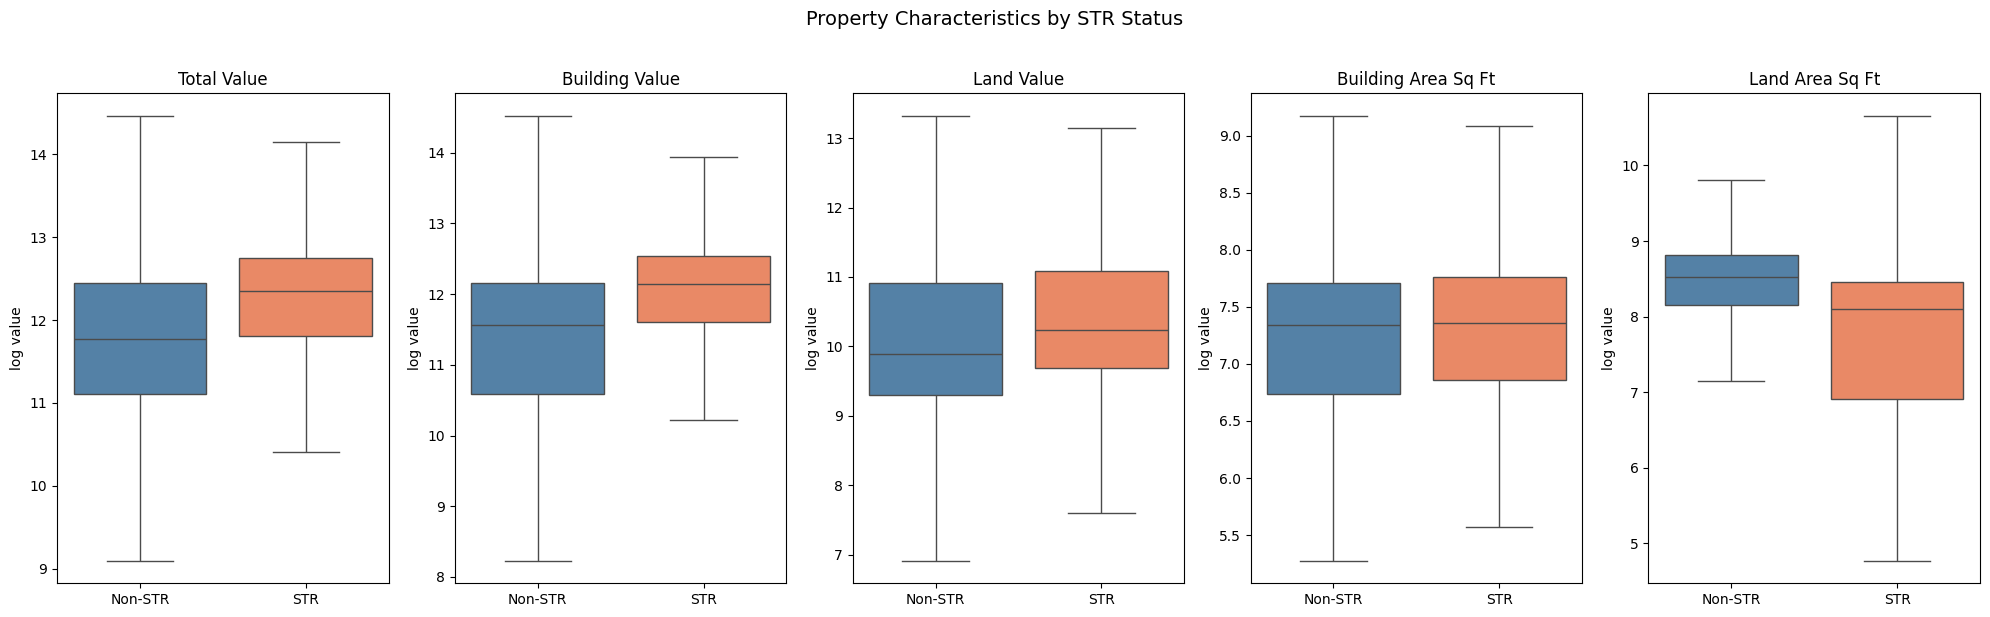

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns

log_vars = ['log_total_value', 'log_building_value', 'log_land_value', 
            'log_building_area_sq_ft', 'log_land_area_sq_ft']

fig, axes = plt.subplots(1, len(log_vars), figsize=(4 * len(log_vars), 6))

for i, var in enumerate(log_vars):
    ax = axes[i]
    sns.boxplot(data=merged, x='is_str', y=var, ax=ax, 
                palette=['steelblue', 'coral'],
                showfliers=False)
    ax.set_title(var.replace('log_', '').replace('_', ' ').title())
    ax.set_xlabel('')
    ax.set_xticklabels(['Non-STR', 'STR'])
    ax.set_ylabel('log value')

plt.suptitle('Property Characteristics by STR Status', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig('str_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

### II.C.2 Pairplots

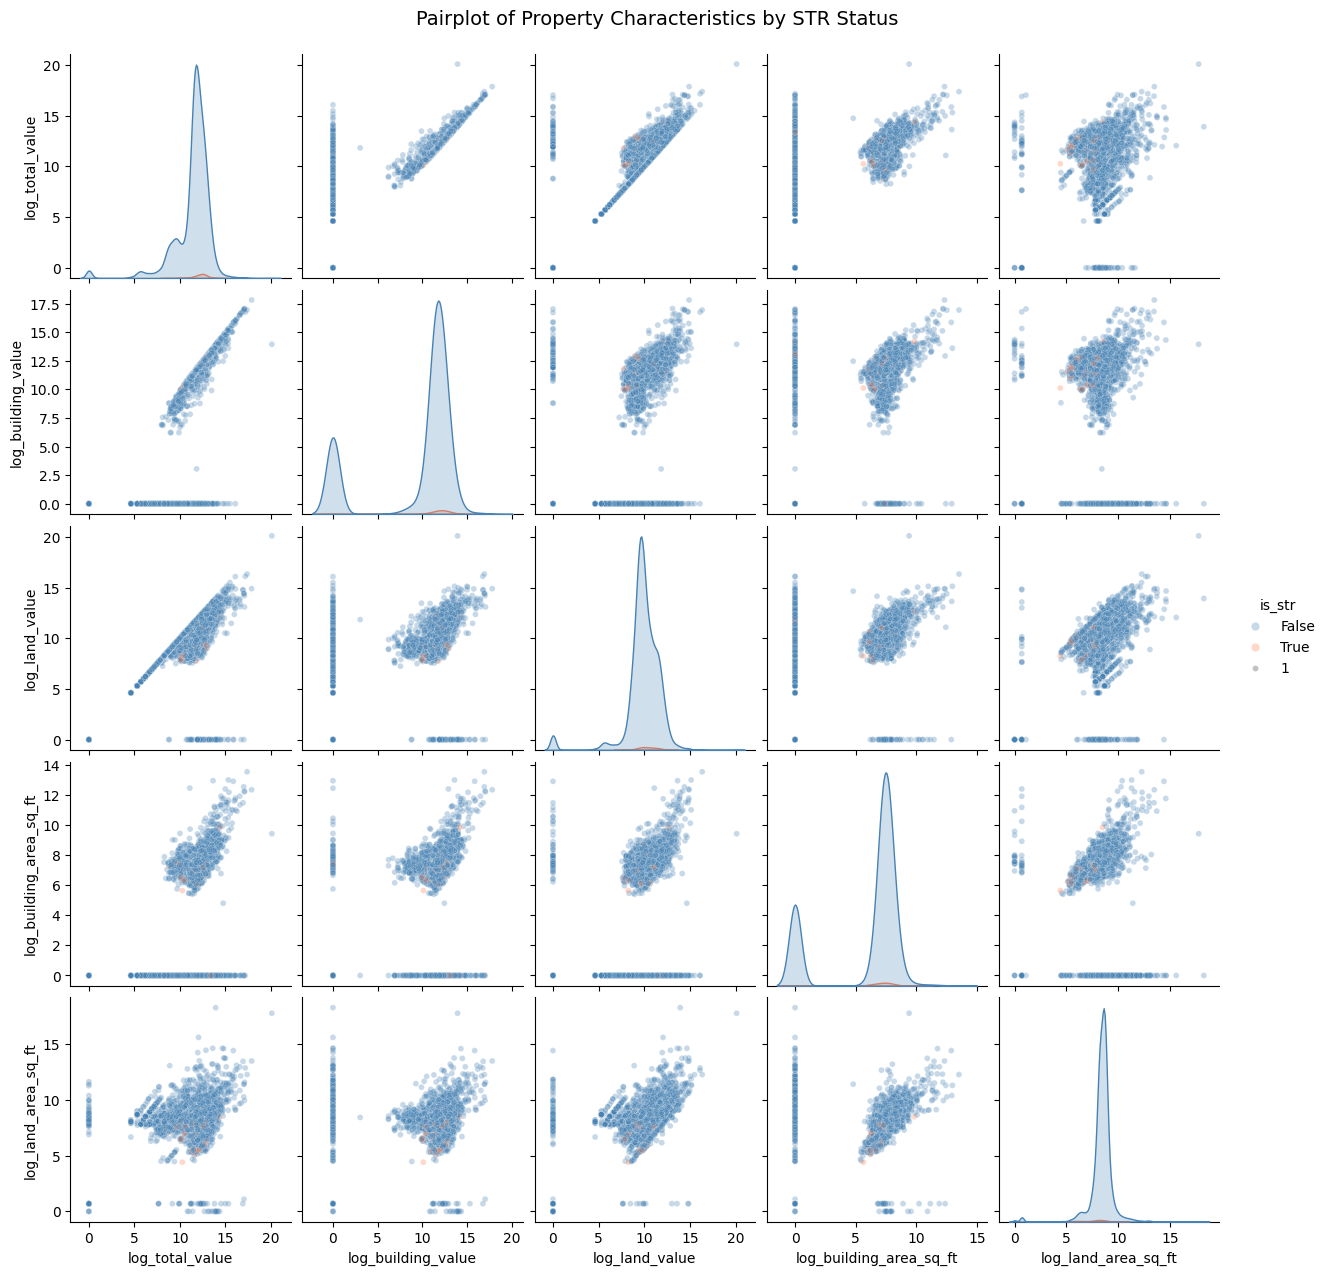

In [95]:
pair_vars = ['log_total_value', 'log_building_value', 'log_land_value',
             'log_building_area_sq_ft', 'log_land_area_sq_ft']

# limit the sample so I'm not running these on 1M+ rows
sample = merged.sample(n=10000, random_state=42)

sns.pairplot(
    sample[pair_vars + ['is_str']],
    hue='is_str',
    palette={False: 'steelblue', True: 'coral'},
    plot_kws={'alpha': 0.3, 'size': 1},
    diag_kind='kde'
)

plt.suptitle('Pairplot of Property Characteristics by STR Status', y=1.02, fontsize=14)
plt.savefig('str_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

### II.C.3 Line Chart
Defining STR entry as a property applying for a permit in year t that did not have a permit in year t-1, and STR exit as the reverse. The line chart shows entry and exit counts by year. The COVID-19 shock in 2020 is evident.

In [96]:
# create variable for /approved/ permit applications
merged['is_str_approved'] = merged['current_status'].isin(['Approved', 'Expired']).astype(int)
print(merged['is_str_approved'].value_counts())

# show number of approvals by year
print(merged.groupby('year')['is_str_approved'].sum())

is_str_approved
0    1100327
1       7779
Name: count, dtype: int64
year
2015.0       0
2016.0       0
2017.0    2423
2018.0    2203
2019.0    1951
2020.0     464
2021.0     738
Name: is_str_approved, dtype: int64


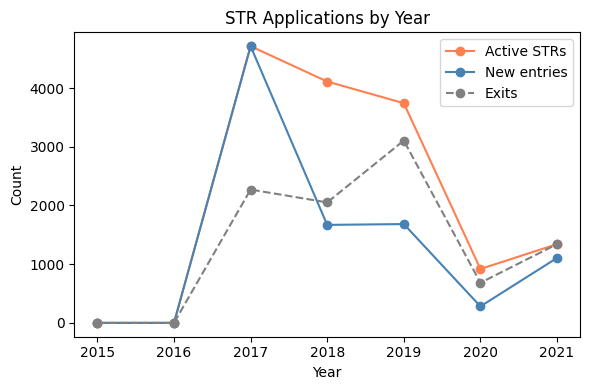

  year  total_properties  str_count  str_entries  str_exits
2015.0            158508          0            0          0
2016.0            159086          0            0          0
2017.0            159551       4713         4713       2271
2018.0            157912       4111         1669       2052
2019.0            157914       3742         1683       3105
2020.0            157667        918          281        683
2021.0            157468       1341         1106       1341


In [97]:
# requires creating str_entry and str_exit flags first
merged = merged.sort_values(['property_id', 'year'])
# create lag to try to account for COVID:
merged['is_str_lag'] = merged.groupby('property_id')['is_str'].shift(1)

# true entry: STR this year, but not last year (or first year in the panel)
merged['str_entry'] = (merged['is_str'] == 1) & ((merged['is_str_lag'] == 0) | (merged['is_str_lag'].isna()))
# true exit: not STR this year, but STR last year
merged['is_str_lead'] = merged.groupby('property_id')['is_str'].shift(-1)
merged['str_exit'] = (merged['is_str'] == True) & ((merged['is_str_lead'] == False) | merged['is_str_lead'].isna())

# recompute by year
str_by_year = merged.groupby('year').agg(
    total_properties=('is_str', 'count'),
    str_count=('is_str', 'sum'),
    str_entries=('str_entry', 'sum'),
    str_exits=('str_exit', 'sum')
).reset_index()
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(str_by_year['year'], str_by_year['str_count'],   marker='o', color='coral',      label='Active STRs')
ax.plot(str_by_year['year'], str_by_year['str_entries'], marker='o', color='steelblue',  label='New entries')
ax.plot(str_by_year['year'], str_by_year['str_exits'],   marker='o', color='gray',       label='Exits', linestyle='--')
ax.set_title('STR Applications by Year')
ax.set_xlabel('Year')
ax.set_ylabel('Count')
ax.set_xticks(str_by_year['year'])
ax.legend()

plt.tight_layout()
plt.savefig('str_by_year.png', dpi=150, bbox_inches='tight')
plt.show()

print(str_by_year.to_string(index=False))


### II.C.4 Spatial Distributions of STRs
The map shows the geographic concentration of STR permits across New Orleans. STRs are heavily concentrated adjacent to the French Quarter and Garden District, and in the Marigny, Tremé. These neighborhoods all have high tourist foot traffic and historically significant housing. This spatial clustering motivates the inclusion of census tract fixed effects in the prediction model.

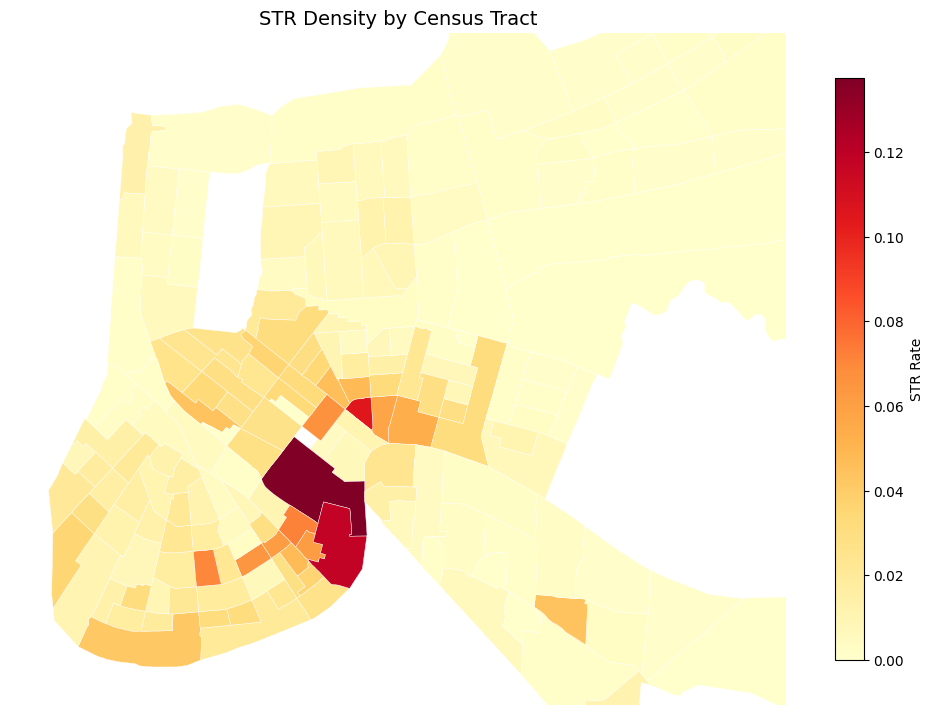

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# attach lat/lon from spatial join geometry
latlon = (pd.DataFrame({
    'property_id': gdf_joined['property_id'],
    'longitude':   gdf_joined.geometry.x,
    'latitude':    gdf_joined.geometry.y
}).drop_duplicates('property_id'))

merged = merged.drop(columns=['latitude', 'longitude'], errors='ignore')
merged = merged.merge(latlon, on='property_id', how='left')

# property-level GeoDataFrame
props_geo = (merged.drop_duplicates('property_id')[['property_id', 'latitude', 'longitude', 'is_str', 'tract_geoid', 'property_class']].dropna(subset=['latitude', 'longitude']))

# STR rate among residential properties by tract
tract_rates = (merged[merged['property_class'] == 'Residential'].groupby('tract_geoid')['is_str'].mean().reset_index(name='str_rate'))
nola_tracts = (tracts[tracts['GEOID'].str.startswith('22071')].merge(tract_rates, left_on='GEOID', right_on='tract_geoid', how='left'))

fig, ax = plt.subplots(figsize=(10, 10))
nola_tracts.dropna(subset=['str_rate']).plot(
    column='str_rate', cmap='YlOrRd', legend=True,
    legend_kwds={'label': 'STR Rate', 'shrink': 0.6},
    edgecolor='white', linewidth=0.3, ax=ax
)
ax.set_title('STR Density by Census Tract', fontsize=14)
ax.set_xlim(-90.15, -89.95)
ax.set_ylim(29.90, 30.05)
ax.set_axis_off()
plt.tight_layout()
plt.show()


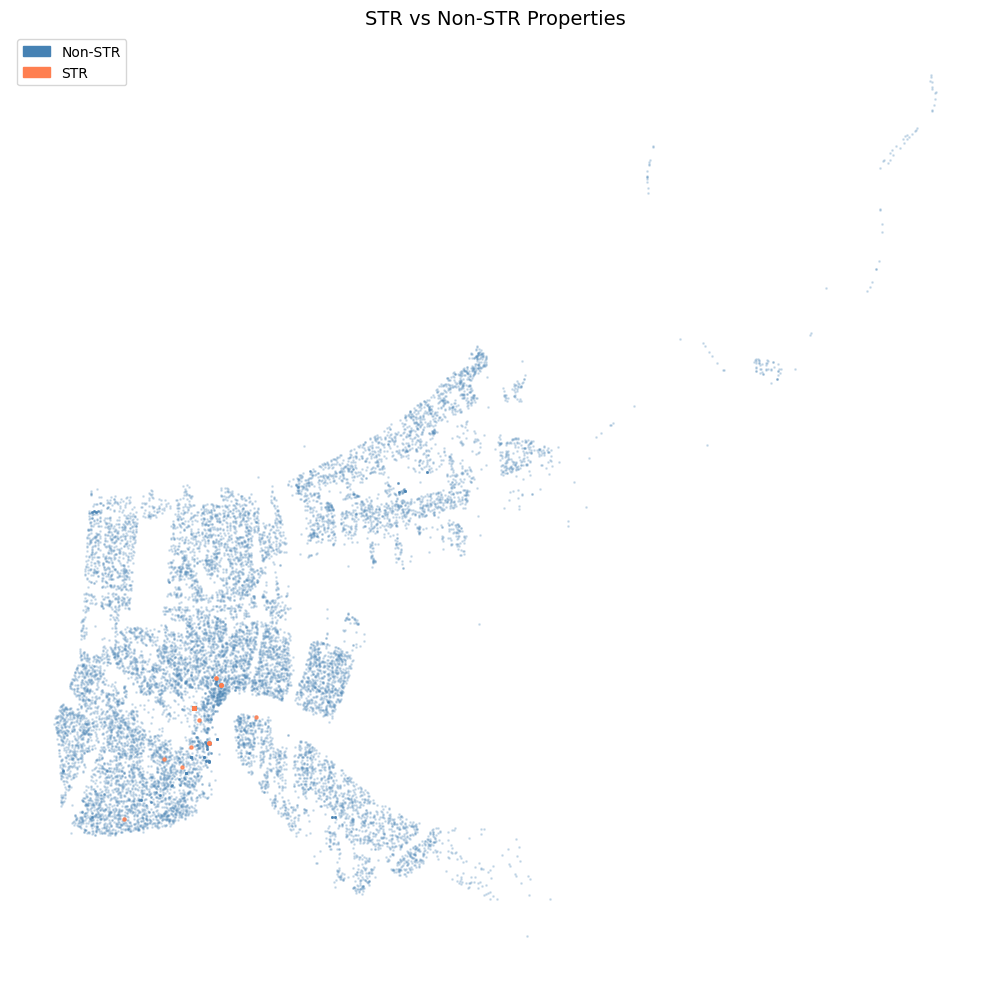

In [105]:
# trying a dot to see if I can get better visibility of individual properties
str_pts     = props_geo[props_geo['is_str']]
non_str_pts = props_geo[~props_geo['is_str']].sample(n=15000, random_state=42)

fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(non_str_pts['longitude'], non_str_pts['latitude'],
           c='steelblue', s=1, alpha=0.2)
ax.scatter(str_pts['longitude'], str_pts['latitude'],
           c='coral', s=5, alpha=0.8)
ax.legend(handles=[
    mpatches.Patch(color='steelblue', label='Non-STR'),
    mpatches.Patch(color='coral',     label='STR')
], loc='upper left')

ax.set_title('STR vs Non-STR Properties', fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

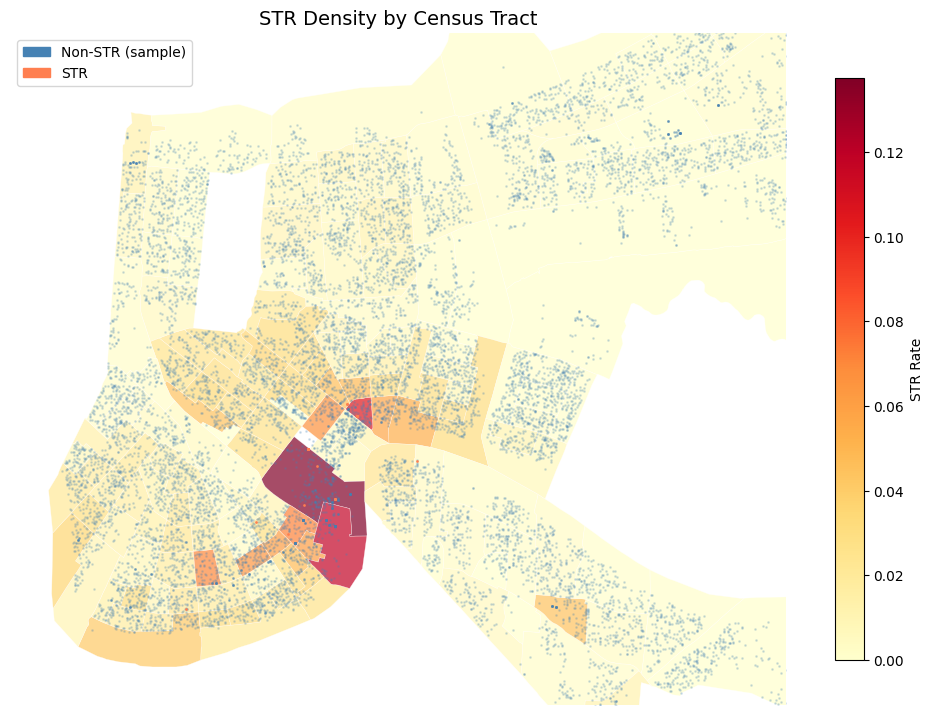

In [ ]:
# try to overlay the two
fig, ax = plt.subplots(figsize=(10, 10))

# choropleth base layer
nola_tracts.dropna(subset=['str_rate']).plot(column='str_rate', cmap='YlOrRd', legend=True,legend_kwds={'label': 'STR Rate', 'shrink': 0.6},edgecolor='white', linewidth=0.3, ax=ax, alpha=0.7)

# dot overlay
ax.scatter(non_str_pts['longitude'], non_str_pts['latitude'],
           c='steelblue', s=1, alpha=0.2)
ax.scatter(str_pts['longitude'], str_pts['latitude'],
           c='coral', s=1, alpha=0.9, zorder=3)

ax.legend(handles=[
    mpatches.Patch(color='steelblue', label='Non-STR (sample)'),
    mpatches.Patch(color='coral',     label='STR')
], loc='upper left')

ax.set_xlim(-90.15, -89.95)
ax.set_ylim(29.90, 30.05)
ax.set_title('STR Density by Census Tract', fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()


### II.C.5 Homestead Rates Over 
Classifyingvcensus tracts as "high STR" or "low STR" based on whether their STR rate exceeds the median tract STR rate. Properties in high-STR tracts show systematically higher assessed values, as expected in areas adjacent to tourism, but higher homestead exemption rates, implying low rates of long-term rentals in those areas.

Median tract STR rate: 0.0072
str_tract_group  High STR tract  Low STR tract
year                                          
2015.0                    0.453          0.450
2016.0                    0.463          0.459
2017.0                    0.469          0.465
2018.0                    0.475          0.469
2019.0                    0.478          0.469
2020.0                    0.475          0.466
2021.0                    0.480          0.467


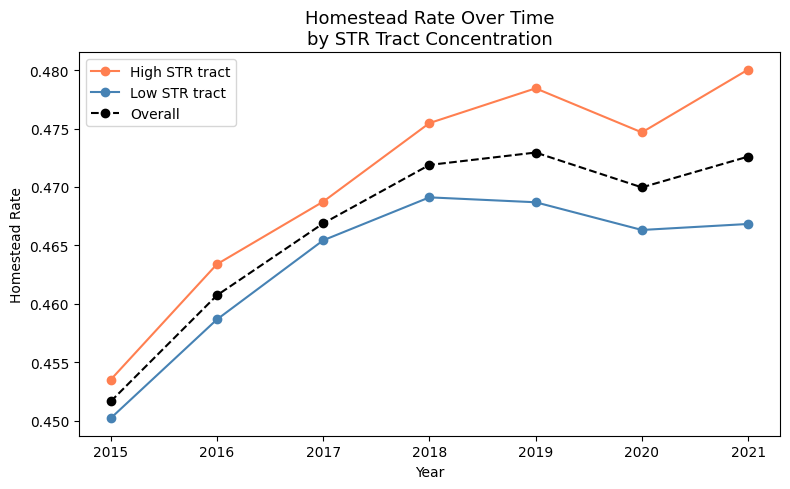

In [108]:
# classify tracts as high/low STR based on median tract_str_rate
tract_median = merged.drop_duplicates('tract_geoid')['tract_str_rate'].median()
print(f"Median tract STR rate: {tract_median:.4f}")

merged['str_tract_group'] = np.where(merged['tract_str_rate'] >= tract_median, 'High STR tract', 'Low STR tract')

# homestead rate by year and tract group — residential only
homestead_by_year = (merged[merged['property_class'] == 'Residential'].groupby(['year', 'str_tract_group'])['is_homestead'].mean().reset_index(name='homestead_rate'))

print(homestead_by_year.pivot(index='year', columns='str_tract_group', values='homestead_rate').round(3))

# overall homestead rate across all tracts
homestead_overall = (merged[merged['property_class'] == 'Residential'].groupby('year')['is_homestead'].mean().reset_index(name='homestead_rate'))

fig, ax = plt.subplots(figsize=(8, 5))

for group, color in [('High STR tract', 'coral'), ('Low STR tract', 'steelblue')]:
    data = homestead_by_year[homestead_by_year['str_tract_group'] == group]
    ax.plot(data['year'], data['homestead_rate'], marker='o', color=color, label=group)

ax.plot(homestead_overall['year'], homestead_overall['homestead_rate'],
        marker='o', color='black', linestyle='--', label='Overall', linewidth=1.5)

ax.set_title('Homestead Rate Over Time\nby STR Tract Concentration', fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('Homestead Rate')
ax.set_xticks(sorted(homestead_by_year['year'].unique()))
ax.legend()
plt.tight_layout()
plt.show()

### II.C.6 Property Value distribution by STR distribution

str_tract_group  High STR tract  Low STR tract
year                                          
2015.0                   11.982         11.523
2016.0                   12.014         11.557
2017.0                   12.102         11.554
2018.0                   12.219         11.563
2019.0                   12.234         11.575
2020.0                   12.374         11.615
2021.0                   12.463         11.637


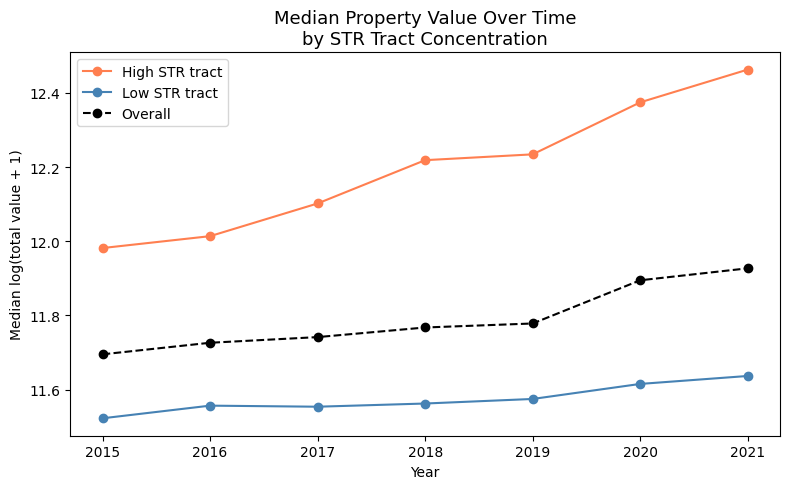

In [ ]:
# median property value by year and tract group — residential only
value_by_year = (merged[merged['property_class'] == 'Residential'].groupby(['year', 'str_tract_group'])['log_total_value'].median().reset_index(name='median_log_value'))
value_overall = (merged[merged['property_class'] == 'Residential'].groupby('year')['log_total_value'].median().reset_index(name='median_log_value'))
print(value_by_year.pivot(index='year', columns='str_tract_group', values='median_log_value').round(3))

fig, ax = plt.subplots(figsize=(8, 5))

for group, color in [('High STR tract', 'coral'), ('Low STR tract', 'steelblue')]:
    data = value_by_year[value_by_year['str_tract_group'] == group]
    ax.plot(data['year'], data['median_log_value'], marker='o', color=color, label=group)

ax.plot(value_overall['year'], value_overall['median_log_value'],
        marker='o', color='black', linestyle='--', label='Overall', linewidth=1.5)

ax.set_title('Median Property Value Over Time\nby STR Tract Concentration', fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('Median log(total value + 1)')
ax.set_xticks(sorted(value_by_year['year'].unique()))
ax.legend()
plt.tight_layout()
plt.show()


---
# III. Proposed Models
## III.A Model A: Predict STR Entry
**Research question:** Which property characteristics predict whether a property will apply for an STR permit?  
**Dependent variable:** `str_entry` binary: 1 if property applied for STR permit this year, having not applied last year  
**Independent variables:** `log_total_value`, `log_building_value`, `log_land_value`, `log_building_area_sq_ft`, `log_land_area_sq_ft`, `is_homestead`, `property_class`, `sale_occurred` (lagged), `tract_geoid` fixed effects  
**Method:** Potentiall a KNN. KNN estimates the probability of STR entry for each property by finding the K most similar properties (based on assessed value, size, 
location, and homestead status) and computing the share that entered the STR market. The output predicted probability serves as a **propensity score**, which can be integrated into a linear regression difference-indifferences linear regression to assess policy imapct, for a policy-relevant application.  
**Validation:** Train/test split by year (train on 2017–2019, test on 2020–2021) to utilize shock. Tune using k-fold cross-validation on the training set. Evaluate with MSE/MAE. Features will be standardized (z-score) before fitting since KNN is distance-based and sensitive to scale.


## III.B Model B: Predict STR Exit & LTR Vulnerability
**Research question:** Among properties that enter the STR market, which are most likely to exit and return to long-term use?  
**Dependent variable:**  binary: 1 if property had a permit last year but not this year  
**Independent variables:** Same property characteristics as Model 1, plus STR permit history variables.  
**Method:** Random forest classifier, restricted to the subset of properties that have ever held an STR permit. The predicted exit probability serves as a **policy targeting score**: properties with low exit probability are good candidates for permit awards, as they are less likely to be suitable long-term housing. The current allotment process is a random lottery per block, so this could improve efficiency.    
**Validation:** Same train/test split as above. Evaluate with precision-recall.  

---

### Github

In [110]:
cd "/Users/mayagore/Library/CloudStorage/OneDrive-TulaneUniversity/26S Data Science/Project/"
jupyter nbconvert --to html "STR address level_M2.ipynb"

SyntaxError: invalid syntax (424816756.py, line 1)